### Analyse des résultats du questionnaire de validation de V2 sur les prompts de Dr. Garrabe

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [68]:
df_all = pd.read_csv('questionnaire_responses.csv')

rating_columns = [col for col in df_all.columns if 'Fidélité' in col or 'Cohérence' in col]
df = df_all[rating_columns].copy()

df.head(10)

,p01: Fidélité au prompt / Similarity to prompt,p01: Cohérence de la scène / Scene coherence,p02: Fidélité au prompt / Similarity to prompt,p02: Cohérence de la scène / Scene coherence,p04: Fidélité au prompt / Similarity to prompt,p04: Cohérence de la scène / Scene coherence,p05: Fidélité au prompt / Similarity to prompt,p05: Cohérence de la scène / Scene coherence,p06: Fidélité au prompt / Similarity to prompt,p06: Cohérence de la scène / Scene coherence,...,p26: Fidélité au prompt / Similarity to prompt,p26: Cohérence de la scène / Scene coherence,p27: Fidélité au prompt / Similarity to prompt,p27: Cohérence de la scène / Scene coherence,p28: Fidélité au prompt / Similarity to prompt,p28: Cohérence de la scène / Scene coherence,p29: Fidélité au prompt / Similarity to prompt,p29: Cohérence de la scène / Scene coherence,p30: Fidélité au prompt / Similarity to prompt,p30: Cohérence de la scène / Scene coherence
0,10,9,10,10,6,7,10,10,7,10,...,10,10,9,10,10,8,10,10,6,9
1,10,10,10,10,5,10,10,10,8,10,...,10,9,10,10,10,8,10,8,7,10
2,10,9,9,8,7,3,10,8,10,9,...,10,8,10,9,9,6,10,9,5,8
3,9,10,10,9,8,7,9,6,7,8,...,10,10,10,10,10,10,8,8,7,8
4,9,4,7,5,5,4,7,5,6,4,...,10,8,10,8,8,7,10,6,7,3
5,9,9,7,5,7,5,9,8,5,6,...,9,9,10,10,10,10,10,10,3,8
6,9,7,10,8,5,6,10,8,4,8,...,10,8,9,9,10,5,10,9,5,5
7,9,9,10,8,5,5,10,8,5,7,...,9,9,10,10,10,10,7,8,6,9
8,10,10,10,10,10,9,10,8,10,9,...,10,10,10,10,10,10,10,10,9,10
9,10,8,7,4,6,5,9,6,10,8,...,10,6,10,6,10,6,10,7,7,8


In [69]:
rec = []
for col in rating_columns:
    pid = col.split(':')[0].strip()
    metric = 'fidelite' if 'Fidélité' in col else 'coherence'
    for respondant_id, score in enumerate(df[col]):
        rec.append({'id': pid, 'metric': metric, 'respondant_id': respondant_id, 'score': score})

df = pd.DataFrame(rec)
df.head(10)

,id,metric,respondant_id,score
0,p01,fidelite,0,10
1,p01,fidelite,1,10
2,p01,fidelite,2,10
3,p01,fidelite,3,9
4,p01,fidelite,4,9
5,p01,fidelite,5,9
6,p01,fidelite,6,9
7,p01,fidelite,7,9
8,p01,fidelite,8,10
9,p01,fidelite,9,10


In [70]:
prompts = sorted(df['id'].unique())
df.head(10)

,id,metric,respondant_id,score
0,p01,fidelite,0,10
1,p01,fidelite,1,10
2,p01,fidelite,2,10
3,p01,fidelite,3,9
4,p01,fidelite,4,9
5,p01,fidelite,5,9
6,p01,fidelite,6,9
7,p01,fidelite,7,9
8,p01,fidelite,8,10
9,p01,fidelite,9,10


In [71]:
desc = df.groupby(['id', 'metric'])['score'].agg(mean='mean', median='median', std='std', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), min='min', max='max').round(4)

desc 

mean  median     std   q25   q75  min  max
id  metric                                                 
p01 coherence  9.0000     9.0  1.3933   9.0  10.0    4   10
    fidelite   9.3714    10.0  0.9420   9.0  10.0    7   10
p02 coherence  7.7143     8.0  2.1084   6.5  10.0    3   10
    fidelite   8.6000     9.0  1.5568   7.0  10.0    6   10
p04 coherence  7.0857     7.0  2.1743   5.0   9.0    2   10
    fidelite   7.1714     7.0  1.8228   6.0   8.5    4   10
p05 coherence  7.5429     8.0  2.4295   6.5  10.0    1   10
    fidelite   9.0857    10.0  1.2919   8.5  10.0    6   10
p06 coherence  8.2571     8.0  1.7037   8.0  10.0    3   10
    fidelite   7.8286     8.0  1.7233   7.0  10.0    4   10
p08 coherence  9.0571    10.0  1.7647   9.0  10.0    2   10
    fidelite   9.7429    10.0  0.6572  10.0  10.0    7   10
p09 coherence  6.8286     7.0  3.1106   5.0  10.0    1   10
    fidelite   3.3429     3.0  1.9088   2.0   4.0    1    8
p10 coherence  9.1714    10.0  1.2945   8.5  10.0    5   10
    fidelite   8.9714    10.0  1.4035   8.0  10.0    4   10
p11 coherence  9.2286    10.0  1.6465   9.0  10.0    2   10
    fidelite   9.6286    10.0  0.8774  10.0  10.0    6   10
p12 coherence  7.8857    10.0  2.9682   6.0  10.0    1   10
    fidelite   3.9714     4.0  1.9476   2.5   5.0    1   10
p13 coherence  8.0571     9.0  2.1821   6.5  10.0    2   10
    fidelite   8.6286     9.0  1.6992   8.0  10.0    2   10
p14 coherence  9.1714    10.0  1.2945   9.0  10.0    6   10
    fidelite   9.4571    10.0  0.8168   9.0  10.0    8   10
p15 coherence  8.7429    10.0  1.8996   8.0  10.0    1   10
    fidelite   9.3429    10.0  0.9375   9.0  10.0    7   10
p17 coherence  8.2286     9.0  2.0876   8.0  10.0    1   10
    fidelite   7.7143     8.0  1.9338   6.0   9.0    4   10
p18 coherence  7.7714     8.0  2.2892   7.0  10.0    1   10
    fidelite   6.0571     7.0  1.6793   4.5   7.0    3    8
p19 coherence  6.8857     7.0  2.3486   5.5   9.0    2   10
    fidelite   7.5429     8.0  1.5018   7.0   9.0    4   10
p20 coherence  8.4571     9.0  1.7879   7.5  10.0    4   10
    fidelite   6.4000     7.0  1.5185   5.5   7.0    2    9
p21 coherence  8.5143     9.0  1.7213   8.0  10.0    3   10
    fidelite   6.9429     7.0  1.7140   6.0   8.0    3   10
p22 coherence  9.2000    10.0  1.3240   9.0  10.0    6   10
    fidelite   9.6571    10.0  0.6835  10.0  10.0    8   10
p23 coherence  4.1143     4.0  2.5178   2.5   5.0    1   10
    fidelite   3.8571     3.0  1.9119   2.0   5.0    1    8
p24 coherence  9.0571    10.0  1.6078   8.5  10.0    3   10
    fidelite   9.2286    10.0  1.6992   9.5  10.0    3   10
p25 coherence  9.5143    10.0  1.0947   9.0  10.0    5   10
    fidelite   9.4857    10.0  1.1212  10.0  10.0    5   10
p26 coherence  8.6857     9.0  1.6587   8.0  10.0    4   10
    fidelite   9.5714    10.0  0.8840   9.5  10.0    7   10
p27 coherence  8.6857    10.0  1.6587   8.0  10.0    4   10
    fidelite   9.6000    10.0  0.8471   9.5  10.0    6   10
p28 coherence  7.5714     8.0  2.0904   6.5   9.0    1   10
    fidelite   9.5714    10.0  1.1190  10.0  10.0    5   10
p29 coherence  8.7143     9.0  1.4465   8.0  10.0    4   10
    fidelite   9.5429    10.0  0.9500   9.5  10.0    6   10
p30 coherence  7.5714     8.0  2.2134   6.0   9.5    3   10
    fidelite   5.7429     6.0  1.6863   5.0   7.0    2    9

In [72]:
df.groupby('metric')['score'].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
coherence,945.0,8.1746,2.2390,1.0,7.0,9.0,10.0,10.0
fidelite,945.0,8.0021,2.3811,1.0,7.0,9.0,10.0,10.0


/var/folders/1j/ldn487895s14f2qmsf51vwbw0000gn/T/ipykernel_42799/2644826120.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


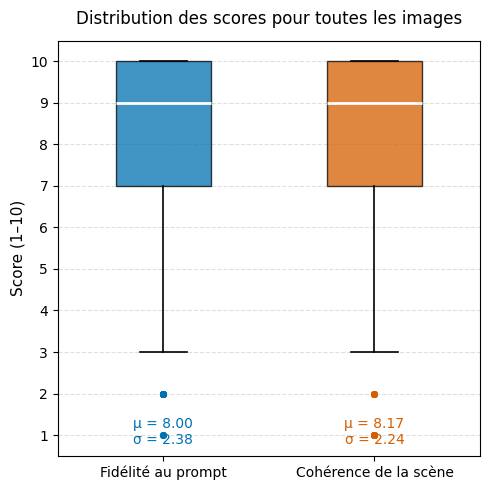

In [73]:
sim_scores = df[df['metric'] == 'fidelite']['score'].values
coh_scores = df[df['metric'] == 'coherence']['score'].values

fig, ax = plt.subplots(figsize=(5, 5))

bp = ax.boxplot(
    [sim_scores, coh_scores],
    labels=['Fidélité au prompt', 'Cohérence de la scène'],
    widths=0.45,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, linestyle='none', alpha=0.4),
)

colors = ['#0072B2', '#D55E00']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

for i, (data, color) in enumerate(zip([sim_scores, coh_scores], colors), start=1):
    ax.text(i, 0.7, f'μ = {np.mean(data):.2f}\nσ = {np.std(data):.2f}',
            ha='center', va='bottom', fontsize=10, color=color)

ax.set_yticks(range(1, 11))
ax.set_ylabel('Score (1–10)', fontsize=11)
ax.set_ylim(0.5, 10.5)
ax.set_title('Distribution des scores pour toutes les images', fontsize=12, fontweight='normal', pad=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('boxplot_combined.png', bbox_inches='tight')
plt.show()

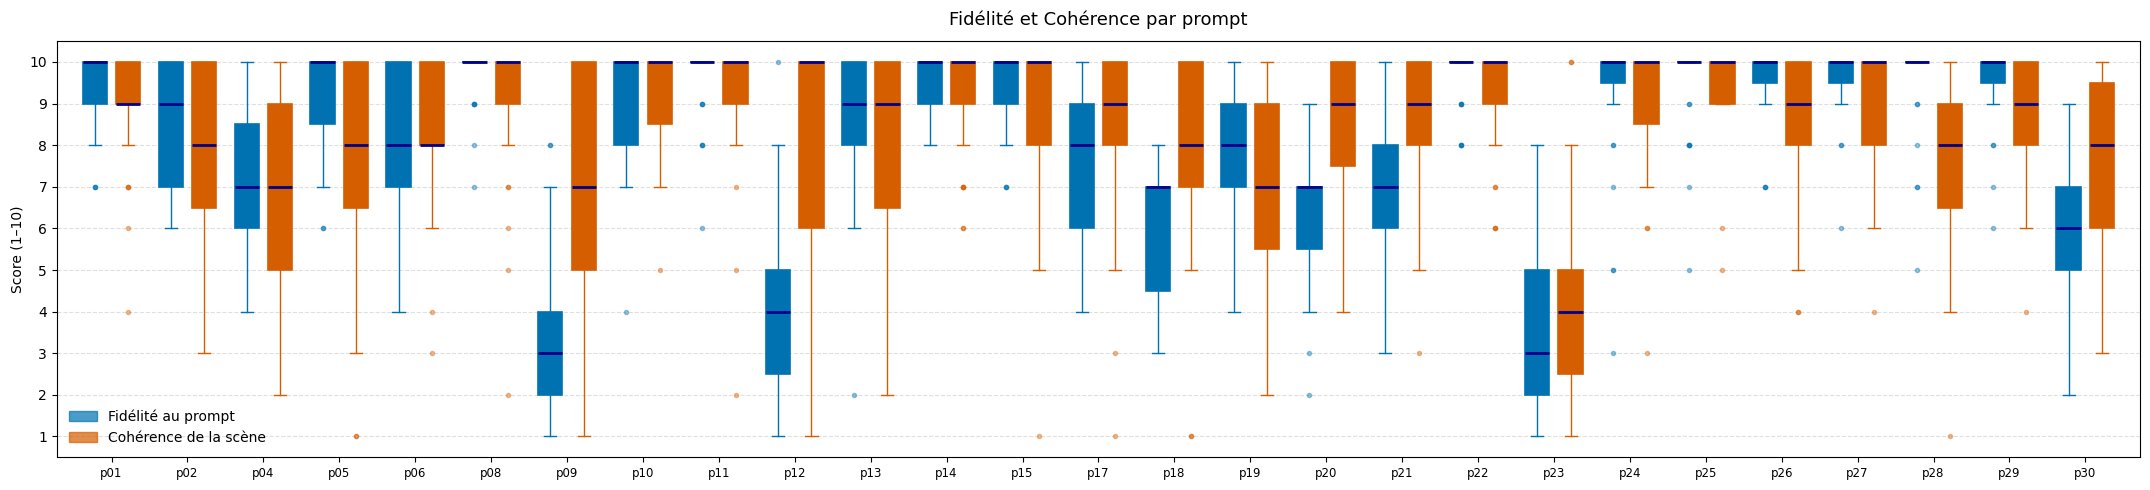

In [74]:
n = len(prompts)
fig, ax = plt.subplots(figsize=(max(14, n * 0.8), 5))

width = 0.32
offsets = {'fidelite': -0.22, 'coherence': +0.22}
colors  = {'fidelite': '#0072B2', 'coherence': '#D55E00'}
labels  = {'fidelite': 'Fidélité au prompt', 'coherence': 'Cohérence de la scène'}

for q in ['fidelite', 'coherence']:
    off   = offsets[q]
    color = colors[q]
    for i, idx in enumerate(prompts):
        x    = i + 1
        data = df[(df['id'] == idx) & (df['metric'] == q)]['score'].values
        if len(data) < 3:
            continue
        ax.boxplot(
            data,
            positions=[x + off],
            widths=width,
            patch_artist=True,
            boxprops=dict(facecolor=color, edgecolor=color, linewidth=1.2),
            medianprops=dict(color='darkblue', linewidth=2),
            whiskerprops=dict(color=color, linewidth=1),
            capprops=dict(color=color, linewidth=1),
            flierprops=dict(marker='o', markersize=3, alpha=0.4,
                            markerfacecolor=color, markeredgecolor=color),
            showfliers=True,
        )

ax.set_xticks(range(1, n + 1))
ax.set_xticklabels(prompts, fontsize=8.5)
ax.set_yticks(range(1, 11))
ax.set_ylabel('Score (1–10)')
ax.set_ylim(0.5, 10.5)
ax.set_title('Fidélité et Cohérence par prompt', fontsize=13, fontweight='normal', pad=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

legend_handles = [mpatches.Patch(color=colors[q], alpha=0.7, label=labels[q]) for q in ['fidelite', 'coherence']]
ax.legend(handles=legend_handles, frameon=False)

plt.tight_layout()
plt.savefig('boxplot_sidebyside.png', bbox_inches='tight')
plt.show()

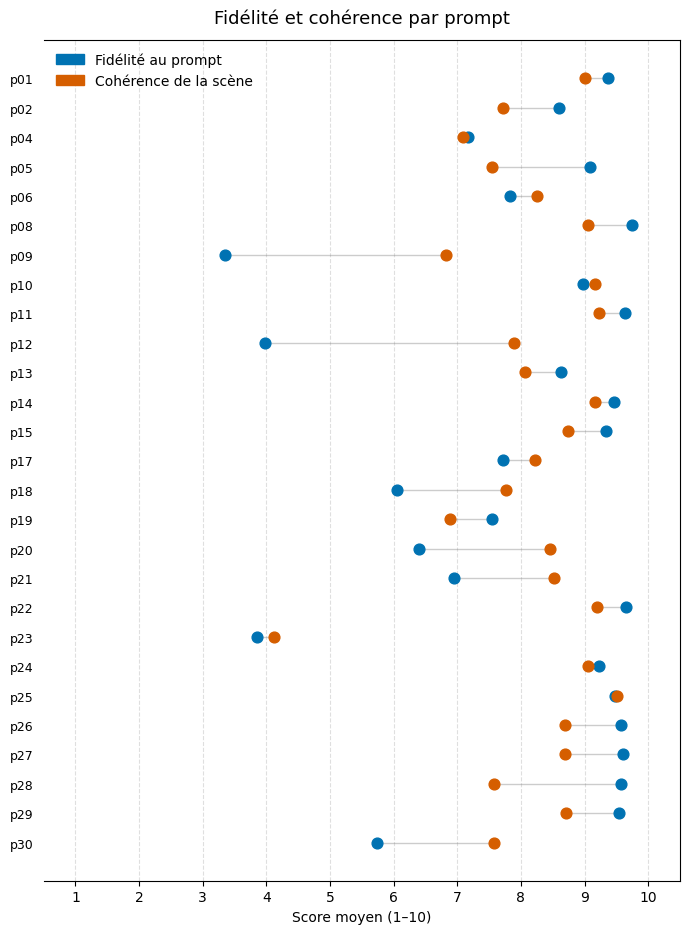

In [75]:
#cleveland dotplot
colors = {'fidelite': '#0072B2', 'coherence': '#D55E00'}
labels = {'fidelite': 'Fidélité au prompt', 'coherence': 'Cohérence de la scène'}

means = df.groupby(['id', 'metric'])['score'].mean().unstack()
means = means.loc[prompts]

fig, ax = plt.subplots(figsize=(7, max(5, n * 0.35)))

for i, idx in enumerate(prompts):
    y = n - i 
    sim_val = means.loc[idx, 'fidelite']
    coh_val = means.loc[idx, 'coherence']
    ax.hlines(y, min(sim_val, coh_val), max(sim_val, coh_val),
              color='grey', linewidth=1, alpha=0.4, zorder=1)
    ax.scatter(sim_val, y, color=colors['fidelite'], s=60, zorder=2)
    ax.scatter(coh_val, y, color=colors['coherence'], s=60, zorder=2)

ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(prompts[::-1], fontsize=9)
ax.set_xticks(range(1, 11))
ax.set_xlabel('Score moyen (1–10)')
ax.set_xlim(0.5, 10.5)
ax.set_title('Fidélité et cohérence par prompt', fontsize=13, fontweight='normal', pad=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

legend_handles = [mpatches.Patch(color=colors[q], label=labels[q]) for q in ['fidelite', 'coherence']]
ax.legend(handles=legend_handles, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('cleveland_dotplot.png', bbox_inches='tight')
plt.show()

## Les outliers

In [76]:
def flag_outliers(df_metric):
    Q1 = df_metric['score'].quantile(0.25)
    Q3 = df_metric['score'].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df_metric = df_metric.copy()
    df_metric['is_outlier'] = ~df_metric['score'].between(lower, upper)
    return df_metric, lower, upper

df_sim = flag_outliers(df[df['metric'] == 'fidelite'])[0]
df_coh = flag_outliers(df[df['metric'] == 'coherence'])[0]

for name, d in [('Fidélité', df_sim), ('Cohérence', df_coh)]:
    n_out = d['is_outlier'].sum()
    print(f"{name}: {n_out} outliers ({100*n_out/len(d):.1f}%)")

print("\nNombres d'outliers par images classés par ordre deescendant:")
outliers_by_pic = pd.concat([df_sim, df_coh])
outliers_by_pic[outliers_by_pic['is_outlier']].groupby('id').size().sort_values(ascending=False).head(10)

Fidélité: 34 outliers (3.6%)
Cohérence: 31 outliers (3.3%)

Nombres d'outliers par images classés par ordre deescendant:


id
p23    19
p09    17
p12    13
p05     2
p13     2
p18     2
p19     2
p04     1
p08     1
p11     1
dtype: int64

In [77]:
print("Outliers fréquents:")
outliers_by_pic[outliers_by_pic['is_outlier']].groupby('respondant_id').size().sort_values(ascending=False).head(10)

Outliers fréquents:


respondant_id
30    15
7      6
16     5
31     4
17     4
4      4
11     4
19     4
5      3
26     3
dtype: int64

In [78]:
# je drop le 30 pour voir
df = df[df['respondant_id'] != 30]

In [79]:
#replot pour voir l'effet:
df.groupby('metric')['score'].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
coherence,918.0,8.2908,2.1092,1.0,7.0,9.0,10.0,10.0
fidelite,918.0,8.0436,2.3616,1.0,7.0,9.0,10.0,10.0


In [80]:
desc = df.groupby(['id', 'metric'])['score'].agg(mean='mean', median='median', std='std', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), min='min', max='max').round(4)

desc

mean  median     std    q25    q75  min  max
id  metric                                                   
p01 coherence  9.0882     9.5  1.3112   9.00  10.00    4   10
    fidelite   9.3824    10.0  0.9539   9.00  10.00    7   10
p02 coherence  7.8529     8.0  1.9715   7.00  10.00    4   10
    fidelite   8.6471     9.5  1.5547   7.00  10.00    6   10
p04 coherence  7.0882     7.0  2.2070   5.00   9.00    2   10
    fidelite   7.2353     7.0  1.8101   6.00   8.75    4   10
p05 coherence  7.7353     8.0  2.1785   7.00  10.00    1   10
    fidelite   9.1471    10.0  1.2585   9.00  10.00    6   10
p06 coherence  8.4118     8.0  1.4589   8.00  10.00    4   10
    fidelite   7.8824     8.0  1.7191   7.00  10.00    4   10
p08 coherence  9.2647    10.0  1.2865   9.00  10.00    5   10
    fidelite   9.7647    10.0  0.6541  10.00  10.00    7   10
p09 coherence  7.0000     7.5  2.9848   5.00  10.00    1   10
    fidelite   3.4118     3.0  1.8929   2.00   4.00    1    8
p10 coherence  9.2059    10.0  1.2975   9.00  10.00    5   10
    fidelite   9.0294    10.0  1.3814   8.25  10.00    4   10
p11 coherence  9.4412    10.0  1.0785   9.00  10.00    5   10
    fidelite   9.6471    10.0  0.8836  10.00  10.00    6   10
p12 coherence  8.0588    10.0  2.8278   6.50  10.00    1   10
    fidelite   4.0294     4.0  1.9460   3.00   5.00    1   10
p13 coherence  8.1471     9.0  2.1480   7.00  10.00    2   10
    fidelite   8.7059     9.0  1.6611   8.00  10.00    2   10
p14 coherence  9.2647    10.0  1.1886   9.00  10.00    6   10
    fidelite   9.5000    10.0  0.7882   9.00  10.00    8   10
p15 coherence  8.9706    10.0  1.3593   8.00  10.00    5   10
    fidelite   9.4118    10.0  0.8570   9.00  10.00    7   10
p17 coherence  8.4412     9.0  1.6912   8.00  10.00    3   10
    fidelite   7.8235     8.0  1.8500   6.00   9.00    4   10
p18 coherence  7.9706     8.0  1.9922   7.00  10.00    1   10
    fidelite   6.0588     7.0  1.7046   4.25   7.00    3    8
p19 coherence  7.0294     7.0  2.2223   6.00   9.00    2   10
    fidelite   7.5294     8.0  1.5223   7.00   9.00    4   10
p20 coherence  8.5000     9.0  1.7965   8.00  10.00    4   10
    fidelite   6.3824     7.0  1.5377   5.25   7.00    2    9
p21 coherence  8.6765     9.0  1.4506   8.00  10.00    5   10
    fidelite   7.0000     7.0  1.7056   6.00   8.00    3   10
p22 coherence  9.2059    10.0  1.3434   9.00  10.00    6   10
    fidelite   9.6471    10.0  0.6912  10.00  10.00    8   10
p23 coherence  4.2059     4.0  2.4958   3.00   5.00    1   10
    fidelite   3.9412     3.5  1.8739   2.25   5.00    1    8
p24 coherence  9.0882    10.0  1.6212   9.00  10.00    3   10
    fidelite   9.2647    10.0  1.7111  10.00  10.00    3   10
p25 coherence  9.5294    10.0  1.1074   9.25  10.00    5   10
    fidelite   9.4706    10.0  1.1345  10.00  10.00    5   10
p26 coherence  8.8235     9.0  1.4662   8.00  10.00    4   10
    fidelite   9.5882    10.0  0.8916  10.00  10.00    7   10
p27 coherence  8.7647    10.0  1.6154   8.00  10.00    4   10
    fidelite   9.6176    10.0  0.8533  10.00  10.00    6   10
p28 coherence  7.7647     8.0  1.7763   7.00   9.00    4   10
    fidelite   9.6471    10.0  1.0410  10.00  10.00    5   10
p29 coherence  8.7353     9.0  1.4628   8.00  10.00    4   10
    fidelite   9.5588    10.0  0.9595  10.00  10.00    6   10
p30 coherence  7.5882     8.0  2.2444   6.00   9.75    3   10
    fidelite   5.8529     6.0  1.5789   5.00   7.00    3    9

/var/folders/1j/ldn487895s14f2qmsf51vwbw0000gn/T/ipykernel_42799/3529185013.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


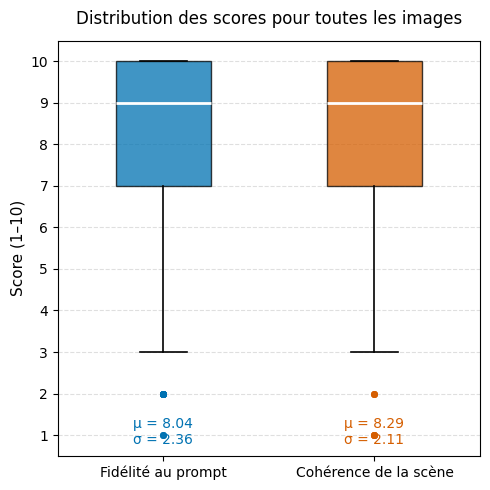

In [81]:
sim_scores = df[df['metric'] == 'fidelite']['score'].values
coh_scores = df[df['metric'] == 'coherence']['score'].values

fig, ax = plt.subplots(figsize=(5, 5))

bp = ax.boxplot(
    [sim_scores, coh_scores],
    labels=['Fidélité au prompt', 'Cohérence de la scène'],
    widths=0.45,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, linestyle='none', alpha=0.4),
)

colors = ['#0072B2', '#D55E00']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for flier, color in zip(bp['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

for i, (data, color) in enumerate(zip([sim_scores, coh_scores], colors), start=1):
    ax.text(i, 0.7, f'μ = {np.mean(data):.2f}\nσ = {np.std(data):.2f}',
            ha='center', va='bottom', fontsize=10, color=color)

ax.set_yticks(range(1, 11))
ax.set_ylabel('Score (1–10)', fontsize=11)
ax.set_ylim(0.5, 10.5)
ax.set_title('Distribution des scores pour toutes les images', fontsize=12, fontweight='normal', pad=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('boxplot_combined_moins30.png', bbox_inches='tight')
plt.show()

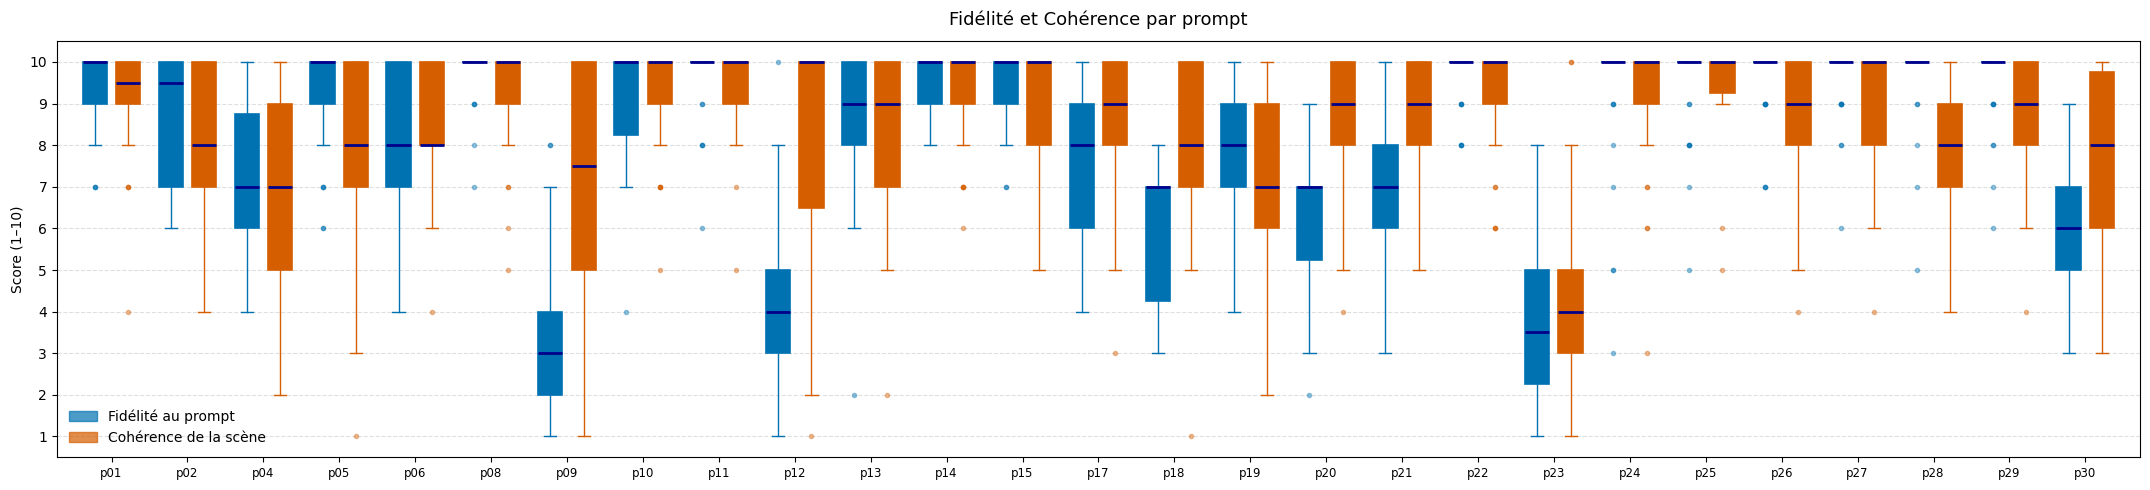

In [82]:
n = len(prompts)
fig, ax = plt.subplots(figsize=(max(14, n * 0.8), 5))

width = 0.32
offsets = {'fidelite': -0.22, 'coherence': +0.22}
colors  = {'fidelite': '#0072B2', 'coherence': '#D55E00'}
labels  = {'fidelite': 'Fidélité au prompt', 'coherence': 'Cohérence de la scène'}

for q in ['fidelite', 'coherence']:
    off   = offsets[q]
    color = colors[q]
    for i, idx in enumerate(prompts):
        x    = i + 1
        data = df[(df['id'] == idx) & (df['metric'] == q)]['score'].values
        if len(data) < 3:
            continue
        ax.boxplot(
            data,
            positions=[x + off],
            widths=width,
            patch_artist=True,
            boxprops=dict(facecolor=color, edgecolor=color, linewidth=1.2),
            medianprops=dict(color='darkblue', linewidth=2),
            whiskerprops=dict(color=color, linewidth=1),
            capprops=dict(color=color, linewidth=1),
            flierprops=dict(marker='o', markersize=3, alpha=0.4,
                            markerfacecolor=color, markeredgecolor=color),
            showfliers=True,
        )

ax.set_xticks(range(1, n + 1))
ax.set_xticklabels(prompts, fontsize=8.5)
ax.set_yticks(range(1, 11))
ax.set_ylabel('Score (1–10)')
ax.set_ylim(0.5, 10.5)
ax.set_title('Fidélité et Cohérence par prompt', fontsize=13, fontweight='normal', pad=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

legend_handles = [mpatches.Patch(color=colors[q], alpha=0.7, label=labels[q]) for q in ['fidelite', 'coherence']]
ax.legend(handles=legend_handles, frameon=False)

plt.tight_layout()
plt.savefig('boxplot_sidebyside_moins30.png', bbox_inches='tight')
plt.show()

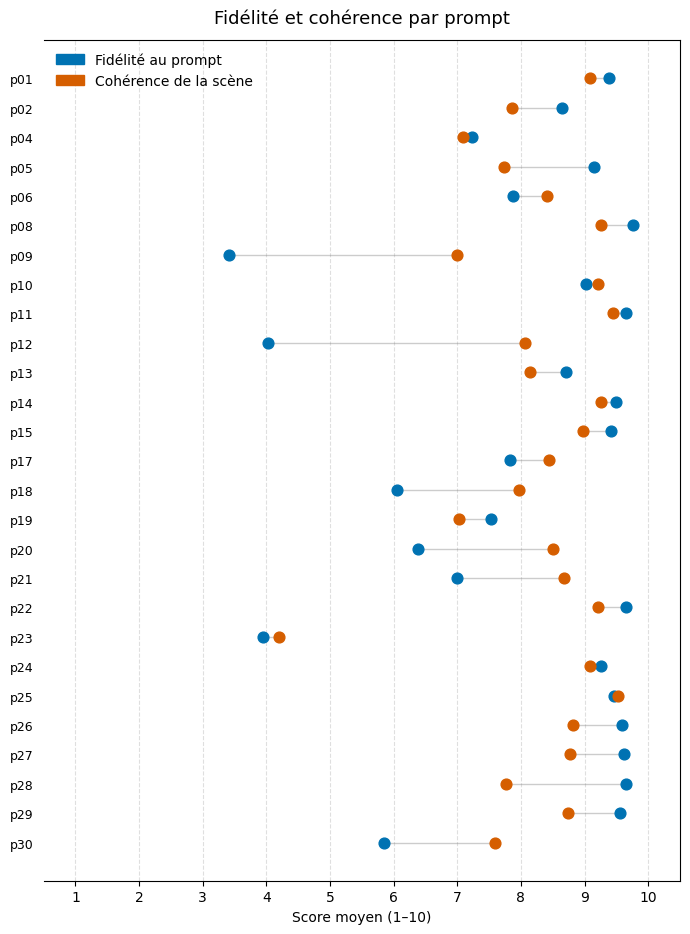

In [83]:
#cleveland dotplot
colors = {'fidelite': '#0072B2', 'coherence': '#D55E00'}
labels = {'fidelite': 'Fidélité au prompt', 'coherence': 'Cohérence de la scène'}

means = df.groupby(['id', 'metric'])['score'].mean().unstack()
means = means.loc[prompts]

fig, ax = plt.subplots(figsize=(7, max(5, n * 0.35)))

for i, idx in enumerate(prompts):
    y = n - i 
    sim_val = means.loc[idx, 'fidelite']
    coh_val = means.loc[idx, 'coherence']
    ax.hlines(y, min(sim_val, coh_val), max(sim_val, coh_val),
              color='grey', linewidth=1, alpha=0.4, zorder=1)
    ax.scatter(sim_val, y, color=colors['fidelite'], s=60, zorder=2)
    ax.scatter(coh_val, y, color=colors['coherence'], s=60, zorder=2)

ax.set_yticks(range(1, n + 1))
ax.set_yticklabels(prompts[::-1], fontsize=9)
ax.set_xticks(range(1, 11))
ax.set_xlabel('Score moyen (1–10)')
ax.set_xlim(0.5, 10.5)
ax.set_title('Fidélité et cohérence par prompt', fontsize=13, fontweight='normal', pad=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

legend_handles = [mpatches.Patch(color=colors[q], label=labels[q]) for q in ['fidelite', 'coherence']]
ax.legend(handles=legend_handles, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('cleveland_dotplot_moins30.png', bbox_inches='tight')
plt.show()